<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Regression-based Rating Score Prediction using Embedding Features**


## **Introduction**


In the previous lab (6.3.3), we trained a neural network to predict user–item interactions (ratings).
While training the neural network, the model also automatically learned the user and item embedding features.

An embedding feature is a small group of numbers that represents hidden features of a user or an item. For example: 
- a user embedding features may represent the user's preferences
- an item embedding features may represent the properties of the item. 

### **Idea of this lab**

In this lab, we will use the learned user embeddings and item embeddings as input features for a regression model. The embedding vectors already contain useful information about users and items. If the embeddings are good, a simple regression model should be able to use them to predict the rating.

We will do: user embedding + item embedding → regression model → rating

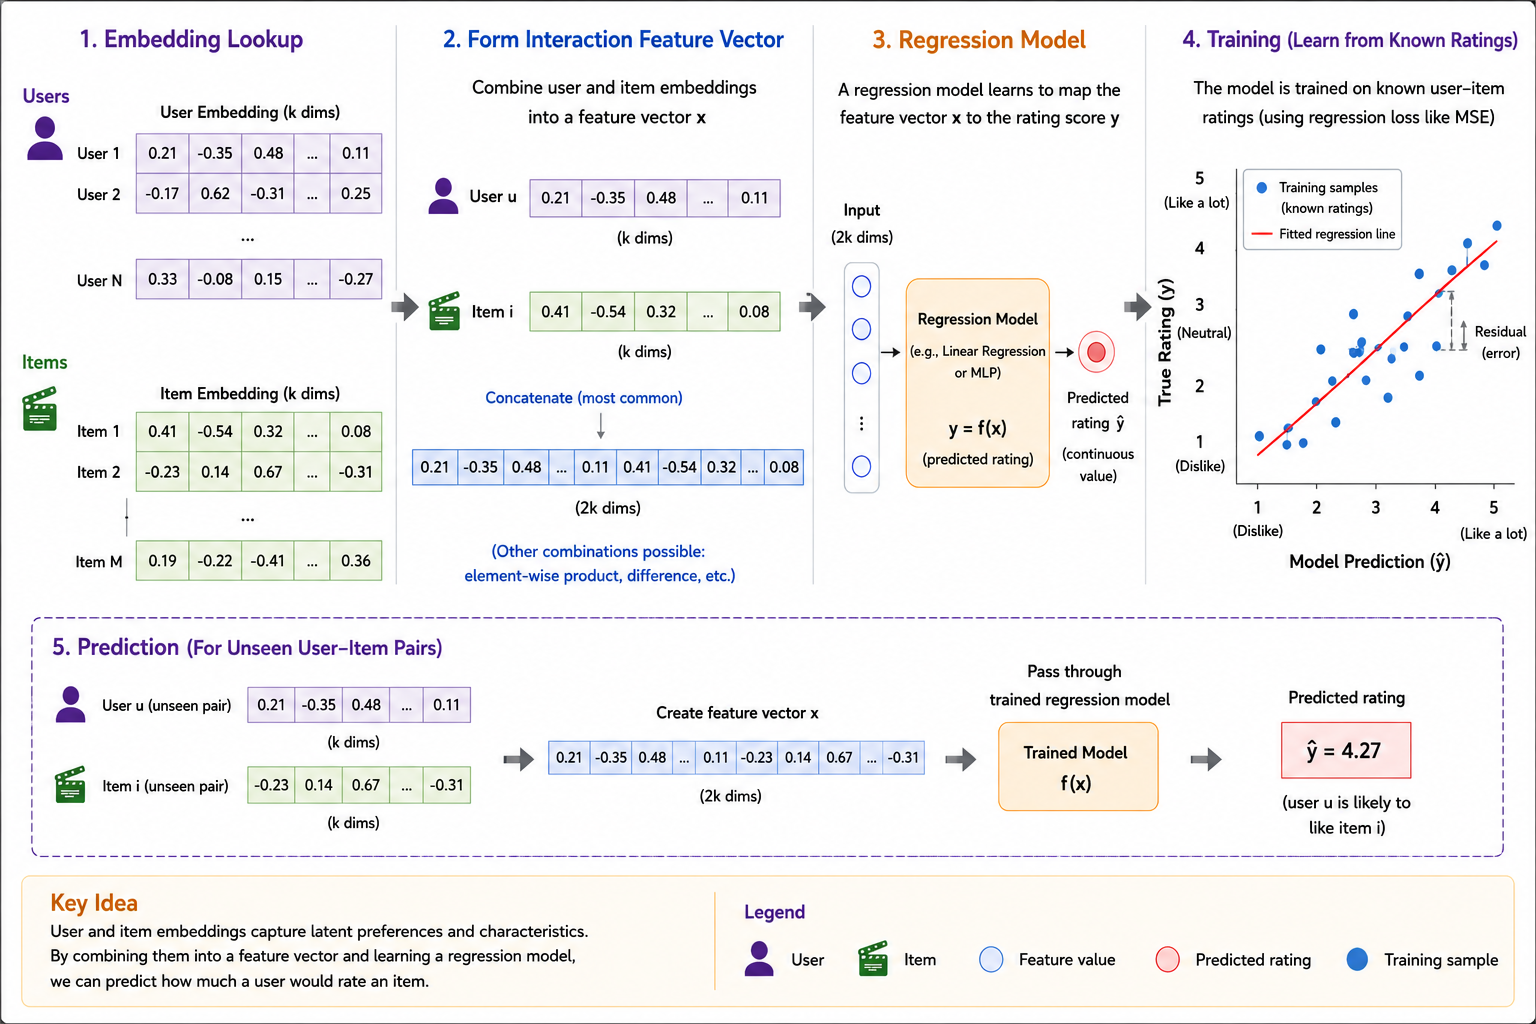

For each user–item pair, we will do the following:
1. get the embedding vector of the user
2. get the embedding vector of the item
3. combine the two embedding vectors into one feature vector
4. use this feature vector as the input `X`
5. use the rating as the output `Y`

This converts the recommendation problem into a normal supervised learning problem. We will try several regression models and compare their performance.

### **Goal of this lab**
Embedding features learned from a neural network can be used as input features for traditional machine learning models.

## **Objectives**


* Build regression models to predict ratings using the combined embedding vectors


----


### **Prepare and setup lab environment**


First install and import required libraries:


In [148]:
# %pip install scikit-learn

In [149]:
import pandas as pd
import numpy as np 

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [150]:
# also set a random state
rs = 123

### **Load embedding datasets**


In [151]:
# rating_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"
rating_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/ratings.csv"

user_emb_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_embeddings.csv"
item_emb_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_embeddings.csv"

The first dataset is the rating dataset that contains a user-item interaction matrix


In [152]:
rating_df = pd.read_csv(rating_url)

In [153]:
rating_df.head()

,user,item,rating
0,1889878,CC0101EN,3.0
1,1342067,CL0101EN,3.0
2,1990814,ML0120ENv3,3.0
3,380098,BD0211EN,3.0
4,779563,DS0101EN,3.0


As you can see from the above data, the user and item are just ids, let's substitute them by their embedding vectors:


In [154]:
# Load user embeddings
user_emb = pd.read_csv(user_emb_url)
# Load item embeddings
item_emb = pd.read_csv(item_emb_url)

In [155]:
user_emb.head()

,user,UFeature0,UFeature1,UFeature2,UFeature3,UFeature4,UFeature5,UFeature6,UFeature7,UFeature8,UFeature9,UFeature10,UFeature11,UFeature12,UFeature13,UFeature14,UFeature15
0,1889878,0.080721,-0.129561,0.087998,0.030231,0.082691,-0.004176,-0.003480,0.091464,-0.040247,0.018958,-0.153328,-0.090143,0.082830,-0.058721,0.057929,-0.001472
1,1342067,0.068047,-0.112781,0.045208,-0.007570,-0.038382,0.068037,0.114949,0.104128,-0.034401,0.004011,0.064832,0.165857,-0.004384,0.053257,0.014308,0.056684
2,1990814,0.124623,0.012910,-0.072627,0.049935,0.020158,0.133306,-0.035366,-0.156026,0.039269,0.042195,0.014695,-0.115989,0.031158,0.102021,-0.020601,0.116488
3,380098,-0.034870,0.000715,0.077406,0.070311,-0.043007,-0.035446,0.032846,-0.060944,0.112384,0.002114,0.090660,-0.068545,0.008967,0.063962,0.052347,0.018072
4,779563,0.106414,-0.001887,-0.017211,-0.042277,-0.074953,-0.056732,0.074610,-0.019367,-0.031341,0.064896,-0.048158,-0.047309,-0.007544,0.010474,-0.032287,-0.083983


In [156]:
item_emb.head()

,item,CFeature0,CFeature1,CFeature2,CFeature3,CFeature4,CFeature5,CFeature6,CFeature7,CFeature8,CFeature9,CFeature10,CFeature11,CFeature12,CFeature13,CFeature14,CFeature15
0,CC0101EN,0.009657,-0.005238,-0.004098,0.016303,-0.005274,-0.000361,-0.015081,-0.012229,0.015686,0.008401,-0.035495,0.009381,-0.032560,-0.007292,0.000966,-0.006218
1,CL0101EN,-0.008611,0.028041,0.021899,-0.001465,0.006900,-0.017981,0.010899,-0.037610,-0.019397,-0.025682,-0.000620,0.038803,0.000196,-0.045343,0.012863,0.019429
2,ML0120ENv3,0.027439,-0.027649,-0.007484,-0.059451,0.003972,0.020496,-0.012695,0.036138,0.019965,0.018686,-0.010450,-0.050011,0.013845,-0.044454,-0.001480,-0.007559
3,BD0211EN,0.020163,-0.011972,-0.003714,-0.015548,-0.007540,0.014847,-0.005700,-0.006068,-0.005792,-0.023036,0.015999,-0.023480,0.015469,0.022221,-0.023115,-0.001785
4,DS0101EN,0.006399,0.000492,0.005640,0.009639,-0.005487,-0.000590,-0.010015,-0.001514,-0.017598,0.003590,0.016799,0.002732,0.005162,0.015031,-0.000877,-0.021283


In [157]:
# Merge user embedding features
user_emb_merged = pd.merge(rating_df, user_emb, how='left', left_on='user', right_on='user').fillna(0)
# Merge course embedding features
merged_df = pd.merge(user_emb_merged, item_emb, how='left', left_on='item', right_on='item').fillna(0)

In [158]:
merged_df.head()

,user,item,rating,UFeature0,UFeature1,UFeature2,UFeature3,UFeature4,UFeature5,UFeature6,...,CFeature6,CFeature7,CFeature8,CFeature9,CFeature10,CFeature11,CFeature12,CFeature13,CFeature14,CFeature15
0,1889878,CC0101EN,3.0,0.080721,-0.129561,0.087998,0.030231,0.082691,-0.004176,-0.003480,...,-0.015081,-0.012229,0.015686,0.008401,-0.035495,0.009381,-0.032560,-0.007292,0.000966,-0.006218
1,1342067,CL0101EN,3.0,0.068047,-0.112781,0.045208,-0.007570,-0.038382,0.068037,0.114949,...,0.010899,-0.037610,-0.019397,-0.025682,-0.000620,0.038803,0.000196,-0.045343,0.012863,0.019429
2,1990814,ML0120ENv3,3.0,0.124623,0.012910,-0.072627,0.049935,0.020158,0.133306,-0.035366,...,-0.012695,0.036138,0.019965,0.018686,-0.010450,-0.050011,0.013845,-0.044454,-0.001480,-0.007559
3,380098,BD0211EN,3.0,-0.034870,0.000715,0.077406,0.070311,-0.043007,-0.035446,0.032846,...,-0.005700,-0.006068,-0.005792,-0.023036,0.015999,-0.023480,0.015469,0.022221,-0.023115,-0.001785
4,779563,DS0101EN,3.0,0.106414,-0.001887,-0.017211,-0.042277,-0.074953,-0.056732,0.074610,...,-0.010015,-0.001514,-0.017598,0.003590,0.016799,0.002732,0.005162,0.015031,-0.000877,-0.021283


### **Create interaction datasets**

Next, we can combine the user features (the column labels starting with `UFeature` and item features (the column labels starting with `CFeature`. *In machine learning, there are many ways to aggregate two feature vectors such as element-wise add, multiply, max/min, average, etc.* Here we simply add the two sets of feature columns:


In [159]:
# Define column names
u_features = [f"UFeature{i}" for i in range(16)]
c_features = [f"CFeature{i}" for i in range(16)]

# Extract embeddings
user_embeddings = merged_df[u_features]
course_embeddings = merged_df[c_features]

# Extract ratings
ratings = merged_df['rating']

regression_dataset = pd.concat([user_embeddings, course_embeddings], axis=1)

# Rename columns (safe)
regression_dataset.columns = [f"Feature{i}" for i in range(regression_dataset.shape[1])]

# Add rating
regression_dataset['rating'] = ratings

# Display
regression_dataset.head()

,Feature0,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,...,Feature23,Feature24,Feature25,Feature26,Feature27,Feature28,Feature29,Feature30,Feature31,rating
0,0.080721,-0.129561,0.087998,0.030231,0.082691,-0.004176,-0.003480,0.091464,-0.040247,0.018958,...,-0.012229,0.015686,0.008401,-0.035495,0.009381,-0.032560,-0.007292,0.000966,-0.006218,3.0
1,0.068047,-0.112781,0.045208,-0.007570,-0.038382,0.068037,0.114949,0.104128,-0.034401,0.004011,...,-0.037610,-0.019397,-0.025682,-0.000620,0.038803,0.000196,-0.045343,0.012863,0.019429,3.0
2,0.124623,0.012910,-0.072627,0.049935,0.020158,0.133306,-0.035366,-0.156026,0.039269,0.042195,...,0.036138,0.019965,0.018686,-0.010450,-0.050011,0.013845,-0.044454,-0.001480,-0.007559,3.0
3,-0.034870,0.000715,0.077406,0.070311,-0.043007,-0.035446,0.032846,-0.060944,0.112384,0.002114,...,-0.006068,-0.005792,-0.023036,0.015999,-0.023480,0.015469,0.022221,-0.023115,-0.001785,3.0
4,0.106414,-0.001887,-0.017211,-0.042277,-0.074953,-0.056732,0.074610,-0.019367,-0.031341,0.064896,...,-0.001514,-0.017598,0.003590,0.016799,0.002732,0.005162,0.015031,-0.000877,-0.021283,3.0


By now, we have built the input dataset `X` and the output vector `y`:


In [160]:
X = regression_dataset.iloc[:, :-1]
y = regression_dataset.iloc[:, -1]
print(f"Input data shape: {X.shape}, Output data shape: {y.shape}")

Input data shape: (233306, 32), Output data shape: (233306,)


### **Perform regression on the interaction dataset**


Now our input data `X` and output `y` are ready, let's build regression models to map X to y and predict ratings. 


You may use `sklearn` to train and evaluate various regression models.


_TODO: First split dataset into training and testing datasets_


In [161]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=rs)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (163314, 32)
X_test shape: (69992, 32)
y_train shape: (163314,)
y_test shape: (69992,)


<details>
    <summary>Click here for Hints</summary>
    
Use `train_test_split()` to split dataset into training and testing datasets.  Use `X, y` as input dataset and output vector. Don't forget to specify `random_state = rs` and `test_size=0.3`.


#### **Linear regression**

_TODO: Create a basic linear regression model_


In [162]:
### WRITE YOUR CODE HERE
linear_regression = LinearRegression()

<details>
    <summary>Click here for Hints</summary>
    
You can call `linear_regression = LinearRegression()` method to create a Linear Regression object


_TODO: Train the basic regression model with training data_


In [163]:
### WRITE YOUR CODE HERE
linear_regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


<details>
    <summary>Click here for Hints</summary>
    
You can call `model.fit()` method with `X_train, y_train` parameters.


_TODO: Evaluate the basic regression model_


In [164]:
y_pred_lr = linear_regression.predict(X_test)
### The main evaluation metric is RMSE but you may use other metrics as well
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 0.19993766678942163


<details>
    <summary>Click here for Hints</summary>
    
You can call `model.predict()` method with `X_test` parameter to get model predictions. Then use `mean_squared_error()` with `y_test, your_predictions` parameters to calculate the RMSE. 


_TODO: Try different regression models such as Ridge, Lasso, ElasticNet and tune their hyperparameters to see which one has the best performance_


#### **Regularization regression**

In [ ]:

models = {
    "Ridge_0.1": Ridge(alpha=0.1),
    "Ridge_1.0": Ridge(alpha=1.0),
    "Ridge_10.0": Ridge(alpha=10.0),
    "Lasso_0.001": Lasso(alpha=0.001, max_iter=10000),
    "Lasso_0.01": Lasso(alpha=0.01, max_iter=10000),
    "Lasso_0.1": Lasso(alpha=0.1, max_iter=10000),
    "ElasticNet_0.001": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    "ElasticNet_0.01": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "ElasticNet_0.1": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append((name, rmse))

results_df = pd.DataFrame(results, columns=["Model", "RMSE"]).sort_values("RMSE")
results_df

,Model,RMSE
0,Ridge_0.1,0.199939
1,Ridge_1.0,0.199962
2,Ridge_10.0,0.200644
6,ElasticNet_0.001,0.209928
3,Lasso_0.001,0.210363
4,Lasso_0.01,0.210363
5,Lasso_0.1,0.210363
7,ElasticNet_0.01,0.210363
8,ElasticNet_0.1,0.210363


In [166]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())  # placeholder, will be replaced by grid
])

param_grid = [
    {
        "model": [Ridge()],
        "model__alpha": [0.1, 1.0, 10.0],
    },
    {
        "model": [Lasso(max_iter=10000)],
        "model__alpha": [0.001, 0.01, 0.1],
    },
    {
        "model": [ElasticNet(max_iter=10000)],
        "model__alpha": [0.001, 0.01, 0.1],
        "model__l1_ratio": [0.2, 0.5, 0.8],
    }
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,estimator,"Pipeline(step...l', Ridge())])"
,param_grid,"[{'model': [Ridge()], 'model__alpha': [0.1, 1.0, ...]}, {'model': [Lasso(max_iter=10000)], 'model__alpha': [0.001, 0.01, ...]}, ...]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [167]:
results_df = pd.DataFrame(grid.cv_results_)
results_df = results_df[
    [
        "param_model",
        "param_model__alpha",
        "param_model__l1_ratio",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]
]


results_df["RMSE"] = np.sqrt(-results_df["mean_test_score"])

results_df["Model"] = results_df["param_model"].astype(str)

final_df = results_df[
    ["Model", "param_model__alpha", "param_model__l1_ratio", "RMSE", "rank_test_score"]
].sort_values("RMSE")

final_df

,Model,param_model__alpha,param_model__l1_ratio,RMSE,rank_test_score
2,Ridge(),10.000,NaN,0.202446,1
1,Ridge(),1.000,NaN,0.202446,2
0,Ridge(),0.100,NaN,0.202446,3
6,ElasticNet(max_iter=10000),0.001,0.2,0.202448,4
7,ElasticNet(max_iter=10000),0.001,0.5,0.202467,5
8,ElasticNet(max_iter=10000),0.001,0.8,0.202502,6
3,Lasso(max_iter=10000),0.001,NaN,0.202530,7
9,ElasticNet(max_iter=10000),0.010,0.2,0.202783,8
10,ElasticNet(max_iter=10000),0.010,0.5,0.203931,9
11,ElasticNet(max_iter=10000),0.010,0.8,0.205582,10


## **Summary**


In this lab, we have built regression models to predict numerical course ratings using the embedding feature vectors extracted from neural networks. In the next lab, we can treat the prediction problem as a classification problem as rating only has two categorical values so classification can be a more natural problem statement.


## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/), Su Wu


Copyright © 2021 IBM Corporation. All rights reserved.


## **Change Log**
| Date (YYYY-MM-DD) | Version | Changed By         | Change Description |
| ----------------- | ------- | ------------------ | ------------------ |
|2026-04-20 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|